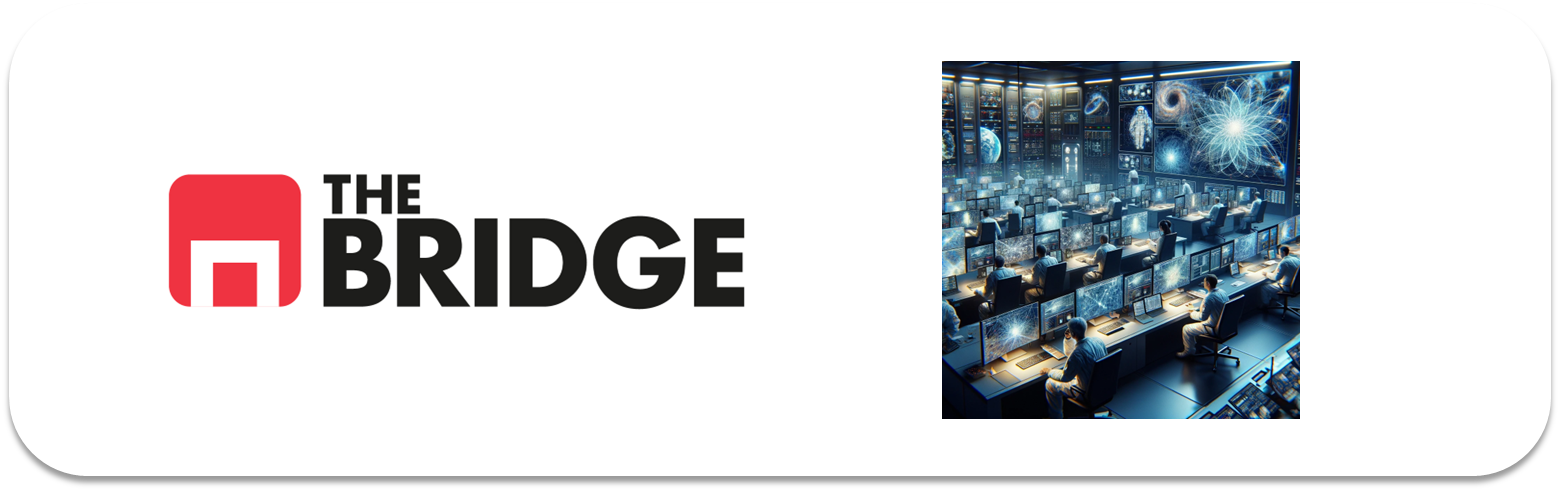

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Evitar que TensorFlow acapare toda la GPU de golpe
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detectada: {gpus}")
else:
    print("No se detectó GPU, se usará CPU.")

print(f"TensorFlow version: {tf.__version__}")

No se detectó GPU, se usará CPU.
TensorFlow version: 2.21.0


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [1]:
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

IM_SIZE = 96

def read_data(directorio, reshape_dim=(96, 96)):
    """
    Lee imágenes organizadas en subcarpetas (una por clase).
    Devuelve arrays X (imágenes) e y (etiquetas texto).
    """
    X = []
    y = []
    for folder in sorted(os.listdir(directorio)):
        folder_path = os.path.join(directorio, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)
                try:
                    image = imread(file_path)
                    # Algunas imágenes pueden ser en escala de grises
                    if len(image.shape) == 2:
                        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
                    image = cv2.resize(image, reshape_dim)
                    X.append(image)
                    y.append(folder)
                except Exception as e:
                    # Saltar archivos corruptos
                    pass
    return np.array(X), np.array(y)

In [4]:
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(IM_SIZE, IM_SIZE))
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (14034, 96, 96, 3), y_train shape: (14034,)


In [5]:
X_test, y_test = read_data(TEST_PATH, reshape_dim=(IM_SIZE, IM_SIZE))
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_test shape: (3000, 96, 96, 3), y_test shape: (3000,)


#### **Reutilización de funciones**

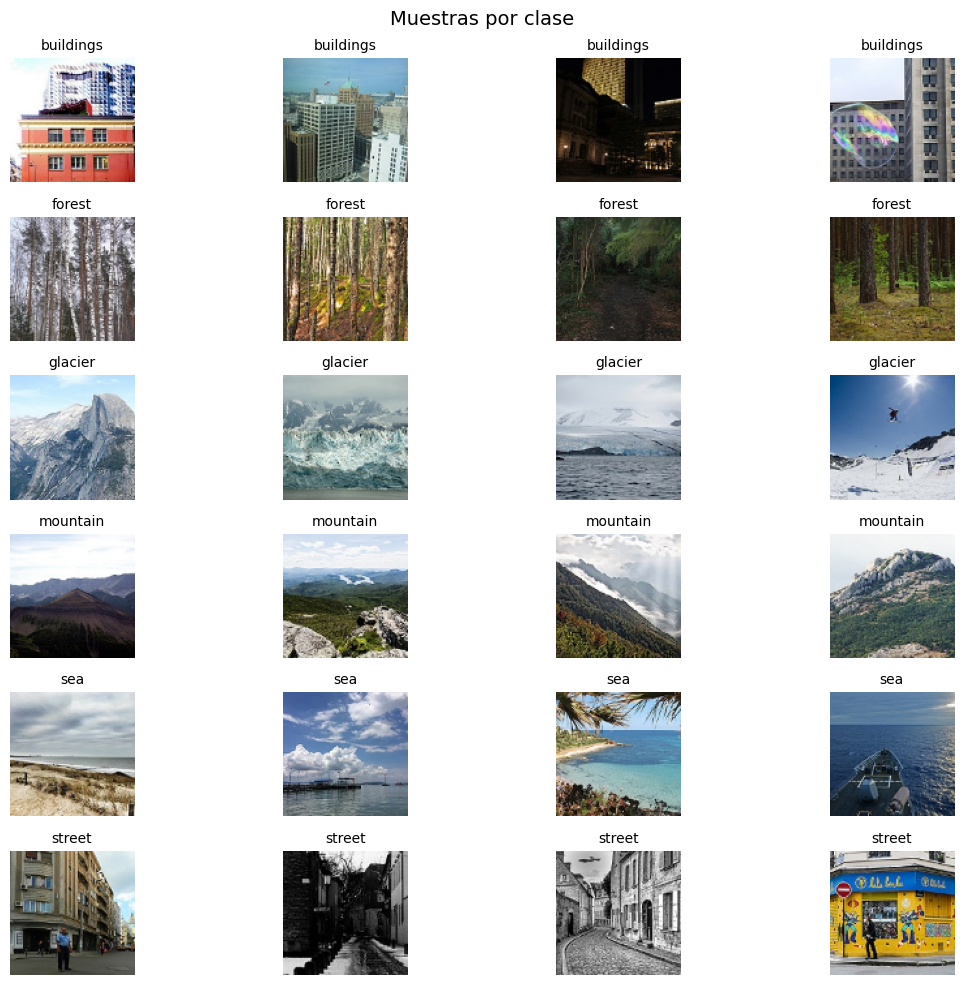

In [8]:
# Clases disponibles
clases = sorted(np.unique(y_train))
n_clases = len(clases)

def plot_samples(X, y, clases, n_per_class=3, figsize=(15, 10)):
    """Muestra n_per_class imágenes aleatorias de cada clase."""
    fig, axes = plt.subplots(len(clases), n_per_class, figsize=figsize)
    for i, clase in enumerate(clases):
        idx = np.where(y == clase)[0]
        chosen = np.random.choice(idx, n_per_class, replace=False)
        for j, ix in enumerate(chosen):
            axes[i, j].imshow(X[ix])
            axes[i, j].set_title(clase, fontsize=10)
            axes[i, j].axis('off')
    plt.suptitle("Muestras por clase", fontsize=14)
    plt.tight_layout()
    plt.show()

# Mostrar muestras
plot_samples(X_train, y_train, clases, n_per_class=4, figsize=(12, 10))

#### **Preprocesamiento de datos con MobileNetV2**

In [9]:
# Codificación de etiquetas 

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Etiquetas numéricas (0-5)
y_test_enc = le.transform(y_test)

# Diccionarios de traducción etiqueta a número

label_to_num = {label: num for num, label in enumerate(le.classes_)}
num_to_label = {num: label for label, num in label_to_num.items()}

# One-hot encoding para la loss categorical_crossentropy

y_train_oh = tf.keras.utils.to_categorical(y_train_enc, n_clases)
y_test_oh = tf.keras.utils.to_categorical(y_test_enc, n_clases)

In [10]:
# Escalado de pixele para la red 

X_train_pp = preprocess_input(X_train.astype(np.float32).copy())
X_test_pp = preprocess_input(X_test.astype(np.float32).copy())

In [11]:
# Barajamos las imágenes de los datasets de imágenes para el entrenamiento

X_train_pp, y_train_oh, y_train_enc_shuf = shuffle(
    X_train_pp, 
    y_train_oh, 
    y_train_enc, 
    random_state=42
)

#### **Transfer Learning con MobileNetV2**

In [12]:
# Carga MobileNetV2 SIN cabeza, CON pesos de ImageNet

base_model_tl = MobileNetV2(
    input_shape=(IM_SIZE, IM_SIZE, 3),
    include_top=False,       # Sin las capas densas de clasificación originales
    weights='imagenet'       # Con los pesos preentrenados en ImageNet
)

In [13]:
# Congelamos las capas del modelo base

for layer in base_model_tl.layers:
    layer.trainable = False

In [14]:
# Construimos la cabeza del modelo de red neuronal 

x = base_model_tl.output
x = layers.GlobalAveragePooling2D()(x)   # Reduce el mapa de features a un vector 1D (más eficiente que Flatten)
x = layers.Dense(256, activation='relu')(x)  # Capa oculta 1
x = layers.Dropout(0.3)(x)                   # Regularización para evitar overfitting
x = layers.Dense(128, activation='relu')(x)  # Capa oculta 2
x = layers.Dropout(0.3)(x)
output = layers.Dense(n_clases, activation='softmax')(x)  # Capa de salida: 6 clases con softmax

In [15]:
# Modelo completo 

model_tl = models.Model(inputs=base_model_tl.input, outputs=output)

In [16]:
# Compilación 

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [17]:
# Summary del modelo con todas la capas 

model_tl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 361,606 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### **Entrenamiento del modelo**

In [18]:
# Early Stopping para ajustar accuracy vs función de pérdida en validación

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  
    verbose=1
)

In [19]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [20]:
# Entrenamiento del modelo 

history_tl = model_tl.fit(
    X_train_pp, y_train_oh,
    validation_split=0.2,   
    batch_size=32,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 53s 138ms/step - accuracy: 0.8556 - loss: 0.4091 - val_accuracy: 0.9138 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 124ms/step - accuracy: 0.9104 - loss: 0.2556 - val_accuracy: 0.9177 - val_loss: 0.2474 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.9230 - loss: 0.2154 - val_accuracy: 0.9184 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9272 - loss: 0.1985
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.9321 - loss: 0.1859 - val_accuracy: 0.9195 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.9458 - loss: 0.1420 - val_accuracy: 0.9166 - val_loss: 0.2428 - learning_rate: 5.0000e-04
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.

In [ ]:
model_tl.evaluate(X_test_pp,y_test_oh) # Valuamos el modelo vs test -> preción del 0.91 (generaliza bien)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9120 - loss: 0.2440


[0.24402280151844025, 0.9120000004768372]

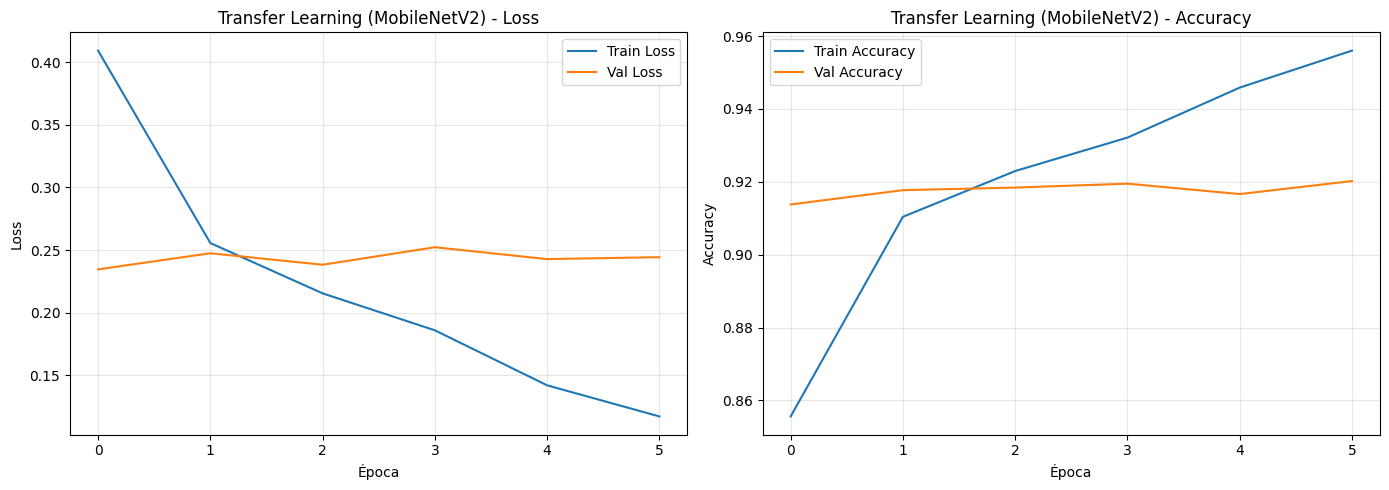

In [23]:
# Evolución del entrenamiento

def plot_history(history, title=""):
    """Grafica loss y accuracy de train vs validation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
    ax2.plot(history.history[acc_key], label='Train Accuracy')
    ax2.plot(history.history[val_acc_key], label='Val Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_tl, title="Transfer Learning (MobileNetV2)")

In [35]:
# Predicciones Transfer Learning                                                                                                   

y_pred_tl = np.argmax(model_tl.predict(X_test_pp, verbose=0), axis=1) 

In [36]:
# Classification Report

print(classification_report(y_test_enc, y_pred_tl, target_names=le.classes_))  

              precision    recall  f1-score   support

   buildings       0.93      0.89      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.86      0.85      0.85       553
    mountain       0.86      0.86      0.86       525
         sea       0.94      0.97      0.96       510
      street       0.91      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



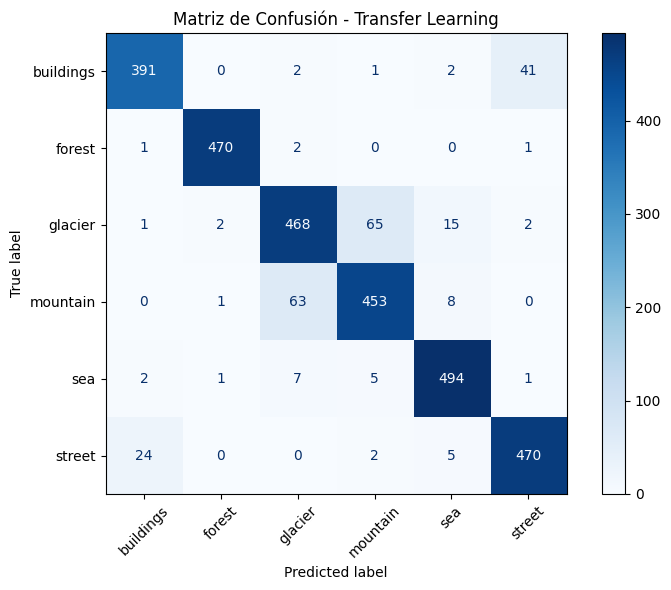

In [37]:
# Matriz de confusión de Transfer Learning

cm_tl = confusion_matrix(y_test_enc, y_pred_tl)
fig, ax = plt.subplots(figsize=(8, 6)) 
ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Matriz de Confusión - Transfer Learning') 
plt.tight_layout()
plt.show()

#### **Fine tunning del modelo**

In [24]:
FINE_TUNE_FROM = len(base_model_tl.layers) - 30

# Primero descongelamos todo el modelo base
base_model_tl.trainable = True

# Luego recongelamos las capas anteriores al punto de corte
for layer in base_model_tl.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

In [25]:
# Verificar cuántas capas son entrenables ahora

trainable_layers = sum(1 for l in model_tl.layers if l.trainable)
frozen_layers = sum(1 for l in model_tl.layers if not l.trainable)

In [26]:
# Recompilamos 

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x más pequeño
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### **Entrenamiento del fine tunning**

- Early Stopping. 
- Entrenamiento del modelo 

In [27]:
early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [28]:
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [29]:
history_ft = model_tl.fit(
    X_train_pp, y_train_oh,
    validation_split=0.2,
    batch_size=32,
    epochs=30,
    callbacks=[early_stop_ft, reduce_lr_ft],
    verbose=1
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.9116 - loss: 0.2490 - val_accuracy: 0.9216 - val_loss: 0.2242 - learning_rate: 1.0000e-05
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.9154 - loss: 0.2349 - val_accuracy: 0.9245 - val_loss: 0.2218 - learning_rate: 1.0000e-05
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9174 - loss: 0.2323 - val_accuracy: 0.9241 - val_loss: 0.2203 - learning_rate: 1.0000e-05
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 119ms/step - accuracy: 0.9194 - loss: 0.2278 - val_accuracy: 0.9252 - val_loss: 0.2192 - learning_rate: 1.0000e-05
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9225 - loss: 0.2186 - val_accuracy: 0.9255 - val_loss: 0.2185 - learning_rate: 1.0000e-05
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 130ms/step - accuracy: 0.9191 - loss: 0.2254 - val_accuracy: 0.9227 - val_loss: 0.2179 - learning_rate: 1.0000e-05
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 11

In [31]:
# Predicciones Fine Tuning

y_pred_ft = np.argmax(model_tl.predict(X_test_pp, verbose=0), axis=1)

In [33]:
# Classification Report

print(classification_report(y_test_enc, y_pred_ft, target_names=le.classes_))

              precision    recall  f1-score   support

   buildings       0.93      0.89      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.86      0.85      0.85       553
    mountain       0.86      0.86      0.86       525
         sea       0.94      0.97      0.96       510
      street       0.91      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



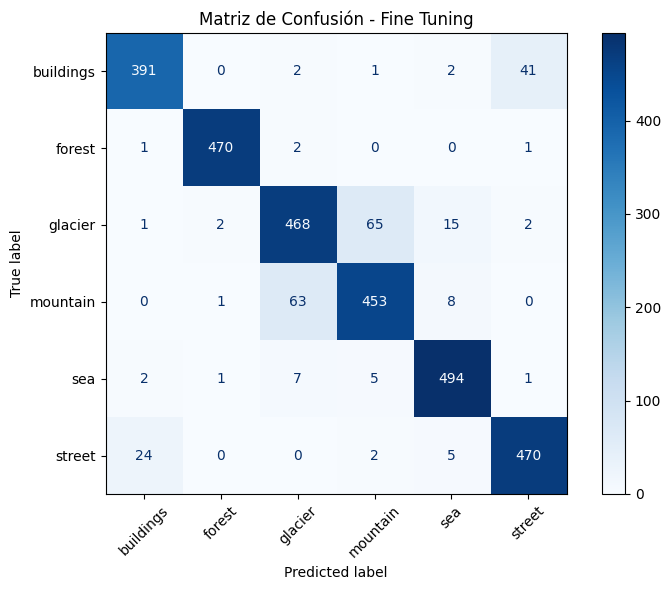

In [34]:
# Matriz de confusión

cm_ft = confusion_matrix(y_test_enc, y_pred_ft)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Matriz de Confusión - Fine Tuning')
plt.tight_layout()
plt.show()